https://github.com/CarolineMortensen/Group_project_CSS.git

All team members have contributed equally to the project.\
Christine Schütt (s224213)\
Caroline Mortensen (s224173)\
Aleks Gryn (s234828)

# Assignment 2

## Imports

In [ ]:
import pickle
import requests
import pandas as pd
import time
from bs4 import BeautifulSoup
import re
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import json
import statistics
import random
from tqdm import tqdm
from multiprocessing import get_context
import multiprocessing as mp
import json
from networkx.readwrite import json_graph


## Part 1: Properties of the real-world network of Computational Social Scientists

> __Exercise: Analyzing Networks through a Random Model__ 
>
>
>
> 1. _Random Network_: Let's start by building a Random Network, acting as a baseline (or ["null model"](https://en.wikipedia.org/wiki/Null_model)) to understand the Computational Social Scientists Network better.  
> * First, calculate the probability (_p_) that makes the expected number of edges in our random network match the actual edge count in the Computational Social Scientists network. Refer to equation 3.2 in your Network Science textbook for guidance. After finding _p_, figure out the average degree (using the given formula). 
> * Now, write a function to generate a Random Network that mirrors the Computational Social Scientists network in terms of node count, using your calculated _p_. Generate a random network by linking nodes in every possible pair with probability _p_. **Hint**: you can use the function [``np.random.uniform``](https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html) to draw samples from a uniform probability distribution.   
> * Visualize the network as you did for the Computational Social Scientists network in the exercise above (my version is below). 
>
> * Answer the following questions __(max 200 words in total)__: 
>    - What regime does your random network fall into? Is it above or below the critical threshold?  
>    - According to the textbook, what does the network's structure resemble in this regime?  
>    - Based on your visualizations, identify the key differences between the actual and the random networks. Explain whether these differences are consistent with theoretical expectations.
>
>   
> 2. _Shortest Paths_: Here, we will check if the Computational Social Scientists Network exhibits characteristics of a small-world network by analyzing its shortest paths.
> * Begin by identifying the largest connected component within the Computational Social Scientists network. Recall that a connected component is a subset of nodes in which every pair of nodes is connected by a path. For a refresher on connected components, see section 2.9 of the Network Science book. Follow these steps:
>    - Utilize [``nx.algorithms.connected_components``](https://networkx.org/documentation/stable//reference/algorithms/generated/networkx.algorithms.components.connected_components.html) to enumerate all connected components, which will be returned as a list of node subsets.
>    - Select the largest subset of nodes identified in the previous step. Then, create a subgraph of your original network that includes only these nodes, using [``nx.Graph.subgraph``](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html). This subset forms your largest connected component, sometimes referred to as the [giant component](https://en.wikipedia.org/wiki/Giant_component).
> * Calculate the average (unweighted) shortest path length within this giant component by employing [``nx.average_shortest_path_length``](https://networkx.org/documentation/networkx-1.3/reference/generated/networkx.average_shortest_path_length.html).
> * Perform the same calculation for the giant component of the random network you constructed in the above exercise 1.
> * Reflect on how the average shortest path lengths of the real and random networks compare and answer the following questions, supporting your answers with the theory from the book.
>   - Why do you think I asked you to consider the giant component only?
>   - Why do you think I asked you to consider unweighted edges?
>   - Does the Computational Social Scientists network exhibit the small-world phenomenon?

#### Random Network

In [ ]:
# Load the JSON file
with open("Group_project_CSS/authors_graph.json", "r") as f:
    data = json.load(f)

# Convert JSON data to a NetworkX graph
authors_graph = json_graph.node_link_graph(data)

# Get number of nodes and edges
N = authors_graph.number_of_nodes()
L = authors_graph.number_of_edges()

print(f"Number of nodes (N): {N}")
print(f"Number of edges (L): {L}")

Number of nodes (N): 17995
Number of edges (L): 57932


In [ ]:
# Calculate the probability
p = (2 * L) / (N * (N - 1))

# Compute the average degree
avg_degree = p * (N - 1)

print(f'Calculated probability: {p}')
print(f'Calculated average degree: {avg_degree}')

Calculated probability: 0.00035782357510235496
Calculated average degree: 6.438677410391775


In [ ]:
# Generate a random network
def generate_random_network(N, p):
    G = nx.Graph()
    G.add_nodes_from(range(N))

    for i in range(N):
        for j in range(i + 1, N):
            if np.random.uniform(0, 1) < p:
                G.add_edge(i, j)

    return G

# Create a random network
random_network = generate_random_network(N, p)

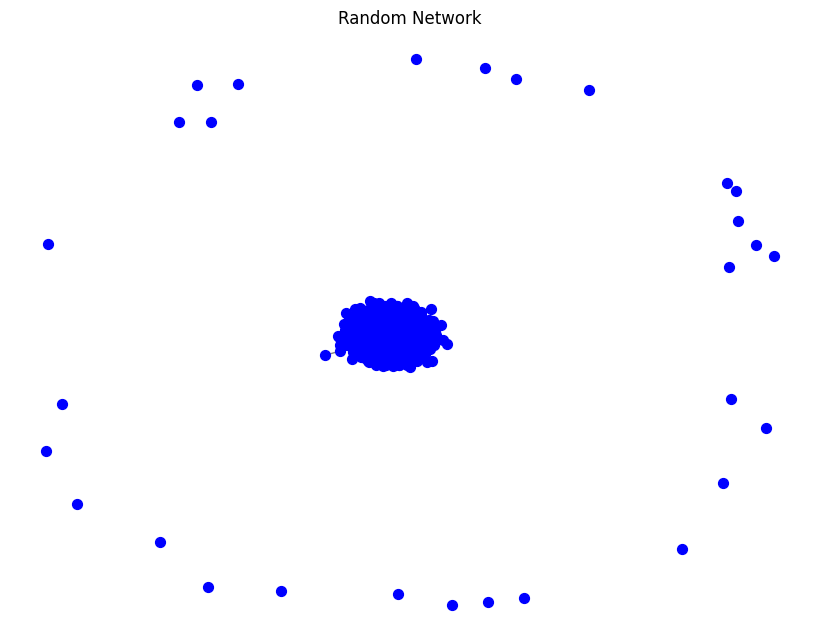

In [ ]:
# Visualize the network
plt.figure(figsize=(8,6))
nx.draw(random_network, node_size=50, node_color='blue', edge_color='gray')
plt.title('Random Network')
plt.show()

#### Shortest Paths

In [ ]:
# Identify the largest connected component
components = list(nx.connected_components(authors_graph))
largest_component = max(components, key=len) # Largest set of nodes

# Create a subgraph containing only the largest component
lcc_graph = authors_graph.subgraph(largest_component).copy()

print(f"Number of nodes in the largest connected component: {lcc_graph.number_of_nodes()}")
print(f"Number of edges in the largest connected component: {lcc_graph.number_of_edges()}")

Number of nodes in the largest connected component: 14571
Number of edges in the largest connected component: 48720


In [ ]:
# Compute the average shortest path length
avg_shortest_path_length = nx.average_shortest_path_length(lcc_graph)
print(f"Average Shortest Path Length in CSS network: {avg_shortest_path_length}")

Average Shortest Path Length in CSS network: 5.689819451739564


In [ ]:
# Compute for the random network
# Finding the largest connected component in the random network
random_components = list(nx.connected_components(random_network))
largest_random_component = max(random_components, key=len)

In [ ]:
# Creating a subgraph for the largest component
random_lcc = random_network.subgraph(largest_random_component).copy()

In [ ]:
# Compute the average shortest path length
avg_shortest_path_length_random = nx.average_shortest_path_length(random_lcc)
print(f"Average Shortest Path Length in Random Network: {avg_shortest_path_length_random}")

Average Shortest Path Length in Random Network: 5.465507996844335


## Part 2: Network Analysis in Computational Social Science

> __Exercise 1: Mixing Patterns and Assortativity__ 
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**
>
> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed _E*10_ swaps, where E is the total number of edges.
> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.
>
>
> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.
>

In [ ]:
# Load the JSON file
with open('/Users/christine/Downloads/authors_graph.json') as f:
    data = json.load(f)
    G = nx.node_link_graph(data)

In [ ]:
#checking the import and data structure
print(G.nodes()['A5009041563'])
print(data.keys())

countries = [data["country"] for _, data in G.nodes(data=True)] #how do i access countries
print(countries)

In [ ]:
def construct_mixing_matrix(data, attribute):
    G = nx.Graph()
    
    #Add nodes with attributes
    for node in data["nodes"]:
        G.add_node(node["id"], **node)

    # Add edges from "links"
    for link in data["links"]:
        G.add_edge(link["source"], link["target"])

    # Get unique categories
    categories = set(nx.get_node_attributes(G, attribute).values())
    category_to_index = {cat: i for i, cat in enumerate(sorted(categories))}
    
    # Initialize mixing matrix
    n = len(categories)
    e = np.zeros((n, n))
    
    # Iterate over edges and count occurrences
    for u, v in G.edges():
        attr_u = G.nodes[u].get(attribute)
        attr_v = G.nodes[v].get(attribute)
        
        if attr_u is not None and attr_v is not None:
            i, j = category_to_index[attr_u], category_to_index[attr_v]
            e[i, j] += 1
            e[j, i] += 1  # Since the graph is undirected

    # Normalize by total number of edges
    e /= e.sum()
    
    return e, category_to_index
e_matrix, category_map = construct_mixing_matrix(data, "country")
print(e_matrix)
print("Category Mapping:", category_map)

In [ ]:
#calculate assortativity coefficient manually
a = e_matrix.sum(axis=0)
b = e_matrix.sum(axis=1)
eii = np.trace(e_matrix)
sum_a_b = np.sum(a * b)
r = (eii - sum_a_b) / (1 - sum_a_b)
print(r)

In [ ]:
# assortative mixing (check of above result)
r = nx.attribute_assortativity_coefficient(G, "country")
r

In [ ]:
def config_doubleswap(G):
    G2 = G.copy()  # creating a copy of original data
    edgelist = set(G2.edges()) # storing the edges used for mixing
    E = len(G.edges())

    # Select two edges
    for i in tqdm(range(E*10)):
        #loop to only swap if conditions are true
        swap = False
        while not swap:
            e1, e2 = random.sample(list(edgelist), 2)

            # ensuring that e_{1}' = (e_{1}[0],e_{2}[1]) and e_{2}' = (e_{2}[0],e_{1}[1]) does not exist
            if (e1[0] != e2[1]) and (e1[1] != e2[0]) and (e1[0] != e2[0]) and (e1[1] != e2[1]):
                old_e1 = e1
                #random flipping 50% of the time
                if int(np.random.choice([True, False])):
                    e1 = (e1[1], e1[0]) 

                e1_new = (e1[0], e2[1])
                e2_new = (e2[0], e1[1])
                
                # ensuring that the newly constructed edges does not already exist in the graph
                if (e1_new not in G2.edges()) and (e2_new not in G2.edges()) and ((e1_new[0] != e1_new[1]) or (e2_new[0] != e2_new[1])):
                    edgelist.remove(old_e1)
                    edgelist.remove(e2)

                    # Update the edge list to reflect the new graph state
                    edgelist.add(e1_new)
                    edgelist.add(e2_new)

                    # Remove the old edges and add the new ones
                    G2.remove_edges_from([e1, e2])
                    G2.add_edges_from([e1_new, e2_new])
                    swap = True

    return G2

G2_shuffled = config_doubleswap(G)

In [ ]:
shuffled_list = []
shuffled_list.append(G2_shuffled)
shuffled_list

In [ ]:
def parallel_run(G):
    p = get_context("fork").Pool(8)
    results = p.map(config_doubleswap, [G for _ in range(8)])
    p.close()
    return results

#number of cpu cores avaliable 
if __name__ == '__main__':
    shuffled_list.append(parallel_run(G))

In [ ]:
from itertools import chain
shuffled_networks  = list(chain.from_iterable(g if isinstance(g, list) else [g] for g in shuffled_list))
shuffled_networks

In [ ]:
import statistics
node_degrees = [deg for _, deg in G2.degree()]

degree_stats = {
    "average": statistics.mean(node_degrees),
    "median": statistics.median(node_degrees),
    "mode": statistics.mode(node_degrees),
    "min": min(node_degrees),
    "max": max(node_degrees),
}

print("Degree Stats:", degree_stats)


In [ ]:
network_density2 = nx.density(G2)
network_density = nx.density(G)
print(f"Network density of shuffled: {network_density2}.")
print(f"Network density of original: {network_density}.")

In [ ]:
#plotting the distributions
original_network = shuffled_networks[0]
shuffled_networks = shuffled_networks[1:]
assortativity_values = [nx.attribute_assortativity_coefficient(G, "country") for G in shuffled_networks]

# Compute assortativity of original network
original_assortativity = nx.attribute_assortativity_coefficient(original_network, "country")

# Plot distribution
plt.figure(figsize=(8, 5))
sns.histplot(assortativity_values, bins=20, kde=True, color="blue", label="Random Networks")
plt.axvline(original_assortativity, color="red", linestyle="dashed", label="Original Network")

# Labels and legend
plt.xlabel("Assortativity (Country)")
plt.ylabel("Frequency")
plt.legend()
plt.title("Distribution of Assortativity in Random Networks vs. Original")
plt.show()

In [ ]:
def assort_check(G2, attribute):
    e_matrix, category_map = construct_mixing_matrix(data, attribute)

    a = e_matrix.sum(axis=0)
    b = e_matrix.sum(axis=1)
    eii = np.trace(e_matrix)
    sum_a_b = np.sum(a * b)
    r = (eii - sum_a_b) / (1 - sum_a_b)
    return r

In [ ]:
G_shuffled = []
for i in range(13):
    G2 = parallel_run(G)
    G_shuffled.append(G2)

G = shuffled_networks[0]
r = assort_check(G, "country")
print(r)

In [ ]:
r_values = []
for i in range(len(shuffled_networks)):
    r = assort_check(shuffled_networks[i], "country")
    r_values.append(r)

r_mean = np.mean(r_values)
r_std = np.std(r_values)

plt.hist(r_values, bins=20)
plt.xlabel("Assortativity Coefficient")
plt.ylabel("Frequency")
plt.title("Assortativity Coefficient Distribution")
plt.show()

> __Exercise 2: Zachary's karate club__: In this exercise, we will work on Zarachy's karate club graph (refer to the Introduction of Chapter 9). The dataset is available in NetworkX, by calling the function [karate_club_graph](https://networkx.org/documentation/stable//auto_examples/graph/plot_karate_club.html)
>
> 1. Visualize the graph. Set the color of each node based on the club split (the information is stored as a node attribute). My version of the visualization is below.
>
> 2. Write a function to compute the __modularity__ of a graph partitioning (use **equation 9.12** in the book). The function should take a networkX Graph and a partitioning as inputs and return the modularity.
> 3. Explain in your own words the concept of _modularity_.
> 4. Compute the modularity of the Karate club split partitioning using the function you just wrote. Note: the Karate club split partitioning is avilable as a [node attribute](https://networkx.org/documentation/networkx-1.10/reference/generated/networkx.classes.function.get_node_attributes.html), called _"club"_.
> 5. Create $1000$ randomized version of the Karate Club network using the _double edge swap_ algorithm you wrote in the exercise above 5. For each of them, compute the modularity of the "club" split and store it in a list.
> 6. Compute the average and standard deviation of the modularity for the random network.
> 7. Plot the distribution of the "random" modularity. Plot the actual modularity of the club split as a vertical line (use [axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html)).
> 8. Comment on the figure. Is the club split a good partitioning? Why do you think I asked you to perform a randomization experiment? What is the reason why we preserved the nodes degree?
> 9.  Use [the Python Louvain-algorithm implementation](https://anaconda.org/auto/python-louvain) to find communities in this graph. Report the value of modularity found by the algorithm. Is it higher or lower than what you found above for the club split? What does this comparison reveal?
> 10.  Compare the communities found by the Louvain algorithm with the club split partitioning by creating a matrix **_D_** with dimension (2 times _A_), where _A_ is the number of communities found by Louvain. We set entry _D_(_i_,_j_) to be the number of nodes that community _i_ has in common with group split _j_. The matrix **_D_** is what we call a [**confusion matrix**](https://en.wikipedia.org/wiki/Confusion_matrix). Use the confusion matrix to explain how well the communities you've detected correspond to the club split partitioning.

## Part 3: Words that characterize Computational Social Science communities

> __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
> What you need for this exercise: 
>    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
>    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)
>
> 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
>   * What does TF stand for? 
>   * What does IDF stand for?
> 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
>   * Consider a community _c_
>   * Find all the abstracts of papers written by a member of community _c_.
>   * Create a long array that stores all the abstract tokens 
>   * Repeat for all the communities. 
> __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).
> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 
>   * Describe similarities and differences between the communities.
>   * Why aren't the TFs not necessarily a good description of the communities?
>   * Next, we calculate IDF for every word. 
>   * What base logarithm did you use? Is that important?
> 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
>   * List the 10 top TF words 
>   * List the 10 top TF-IDF words
>   * List the top 3 authors (by degree)
>   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

__Exercise 2: The Wordcloud__. It's time to visualize our results!

> * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
> * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 
> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

 __Exercise 3: Computational Social Science__ 

> * Go back to Week 1, Exercise 1. Revise what you wrote on the topics in Computational Social Science. 
> * In light of your data-driven analysis, has your understanding of the field changed? How? __(max 150 words)__